# LC-NE Functional Gene Heatmap (Fig S9)

## Purpose

This notebook generates compact summary plots of relative gene expression across LC-NE pseudospace for functionally relevant genes. The goal is to visualize how expression of these genes varies along the pseudospace axis.

Inputs are an snRNA-seq `.h5ad` and a CSV of per-cell pseudospace scores. Outputs are a compiled A4 figure (PNG/PDF, also shown inline) plus supporting CSVs, written to `/results`.

## Methodological Overview

### Inputs

- `data/LCNE-transcriptomics-preprocessing_.../snRNAseq/snRNAseq_LCNE_BN_d4_1-5k.h5ad`: LC-NE single-nucleus RNA-seq AnnData object. The main matrix is a ~1.5k highly-variable-gene (HVG) subset; the full transcriptome (~29k genes, autosomes + MT only) is stored in `adata.raw` as raw counts.
- `output/cellID_pc_0722.csv`: pseudospace score table with cell IDs (`cellID`) and a pseudospace/pseudocluster score column.
- Hard-coded `GENE_PANELS` in this notebook: the curated functional gene categories used for plotting.

### Expression matrix (full transcriptome)

- To plot every curated panel gene, the input is expanded to the full transcriptome via `adata.raw`; the HVG subset alone would drop most panel genes.
- The `logcounts` layer is rebuilt from raw counts as `sc.pp.normalize_total(target_sum=1e4)` then `sc.pp.log1p` (i.e. `log1p` of CP10k). This reproduces the file's original `logcounts` (r ~ 0.99999) for all genes.
- Sex-chromosome genes (chrX/chrY) are absent from this dataset, so a few panel genes (e.g. `Htr2c`, `Gabra3`, `Trpc5`) cannot be plotted; they are written to the missing-gene report.

### Batch handling (dominant batch only)

- The dataset integrates two experimental batches (`experimental_batch_id`), for which a batch-normalized (`BN`) layer exists in the source file.
- This notebook instead restricts to the **dominant batch** (the most frequent `experimental_batch_id`, ~80% of cells), since many genes being plotted are not in HVG set and batch normalized counts are unavailable. Count-based `logcounts` is used for this plot instead of z-score in figure 3b.
- The dominant batch spans the full pseudospace range with roughly constant density across pseudospace bins, so restricting to it does not distort the trajectory.


### Cell ordering

- Cells are matched between the AnnData object and the pseudospace CSV by cell ID, then restricted to the dominant batch.
- Matched cells are sorted by pseudospace score.
- Pseudospace is normalized to a 0-1 scale for plotting and export.

### Smoothing / downsampling (sliding window)

- Expression is smoothed along the pseudospace-ordered cells using an overlapping sliding window.
- The window covers `WINDOW_FRACTION` (15%) of cells, with a minimum size of `MIN_WINDOW_CELLS` (100 cells).
- The smoothed profile is sampled at `N_OUT` (50) evenly spaced pseudospace positions.

### Relative-expression scaling

- For each gene independently, the smoothed expression is scaled from 0 to 1 across the 50 pseudospace positions (row-wise min-max via the shared `heatmap.scaling`).
- 0 = the lowest smoothed value observed for that gene across pseudospace; 1 = the highest.
- This emphasizes the pseudospace expression pattern (shape) rather than absolute magnitude.

### Gene ordering (peak-based)

- Within each functional category, genes are ordered by the pseudospace position of their peak relative expression (`order_rows_by_peak_1_to_0`).
- Genes peaking near pseudospace 1 are placed on the left; genes peaking near pseudospace 0 on the right.
- Center of mass and total intensity are used as tie-breakers.

### Outputs (`/results/fig_S9/`)

- `<basename>.png` / `.pdf`: the compiled A4 figure (also displayed inline).
- `<basename>_essential_data.csv`: long-form per-gene, per-position smoothed logcounts and relative expression.
- `<basename>_missing_genes.csv`: panel genes not found in the data.
- `<basename>_layout.csv`: per-panel layout summary.

In [8]:
from pathlib import Path
import textwrap

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

ROOT = Path("/root/capsule")  # repo root
DATA_PATH = ROOT / "data" / "LCNE-transcriptomics-preprocessing_2026-07-08_16-23-00" / "snRNAseq" / "snRNAseq_LCNE_BN_d4_1-5k.h5ad"
PSEUDOSPACE_CSV = ROOT / "results" / "cell_ID_peudocluster.csv"
OUT_DIR = Path("/results") / "fig_S9"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
CODE_DIR = str(ROOT / "code")
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)
import heatmap  # shared row min-max scaling (heatmap.scaling)

import matplotlib.font_manager as fm
# Register the bundled Helvetica-metric font (TeX Gyre Heros) so panels render in
# Helvetica even when no system Helvetica is installed.
FONT_DIR = ROOT / "code" / "utils"
_HELVETICA_FACES = [
    "texgyreheros-regular.otf", "texgyreheros-bold.otf",
    "texgyreheros-italic.otf", "texgyreheros-bolditalic.otf",
]
for _face in _HELVETICA_FACES:
    _fp = FONT_DIR / _face
    if _fp.exists():
        fm.fontManager.addfont(str(_fp))
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica", "TeX Gyre Heros", "Arial", "DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

EXPRESSION_LAYER = "logcounts"
BATCH_COL = "experimental_batch_id"  # restrict to dominant batch (single batch -> no BN needed)
N_OUT = 50
WINDOW_FRACTION = 0.15
MIN_WINDOW_CELLS = 100
ORDER_MODE = "peak_desc"  # genes peaking near pseudospace 1 are placed left; pseudospace 0 genes right

A4_PORTRAIT_IN = (8.27, 11.69)
DPI = 450
GENE_COLUMN_WIDTH_IN = 0.07
PANEL_GAP_X_IN = 0.16
PANEL_GAP_Y_IN = 0.35
LEFT_MARGIN_IN = 1.00
RIGHT_MARGIN_IN = 1.00
TOP_MARGIN_IN = 1.00
BOTTOM_MARGIN_IN = 1.00
HEADER_HEIGHT_IN = 0.34
HEATMAP_HEIGHT_IN = 0.6375
CBAR_WIDTH_IN = 1.75
CBAR_HEIGHT_IN = 0.16

XTICK_FONTSIZE = 4.2
TITLE_FONTSIZE = 7.2
YTICK_FONTSIZE = 6.0

FIGURE_BASENAME = "LCNE_simplified_relative_peak1to0_notebook"
from datetime import date
FIGURE_NAME = f"fig_S9_{date.today():%Y-%m-%d}"  # dated name for the exported PNG/PDF
print("Output directory:", OUT_DIR)

Output directory: /results/fig_S9


## Gene Panels

These are the final gene panels used for plotting.

In [3]:
GENE_PANELS = {
    "LC/NE markers": [
        "Dbh", "Th", "Ddc", "Slc6a2", "Slc18a2", "Slc10a4", "Aldh9a1", "Slc18a1", "Maoa", "Maob",
    ],
    "Transmitters related": [
        "Gad1", "Gad2", "Slc32a1", "Slc6a1", "Slc6a5", "Slc6a11", "Slc17a6", "Slc1a2",
        "Ache", "Bche", "Prima1", "Slc5a7", "Slc29a1", "Slc29a2", "Slc29a4",
    ],
    "Neuropeptides": [
        "Adcyap1", "Agrp", "Bdnf", "Calca", "Cartpt", "Cpe", "Crh", "Gal", "Nmb", "Npb",
        "Nps", "Pcsk1", "Pcsk2", "Pcsk1n", "Pdyn", "Penk", "Pnoc", "Pomc", "Scg5", "Sst", "Tac1",
    ],
    "Receptors": [
        "Adra1a", "Htr1a", "Htr2a", "Htr2c", "Chrm1", "Chrm2", "Chrm3", "Grm1", "Grm5",
        "Oprl1", "Oprm1", "Hcrtr1", "Gabbr1", "Gabbr2", "Adora1", "Adora2a", "Cnr1", "Sstr2",
        "Adcyap1r1", "Calcr", "Crhr1", "Crhr2", "Crcp", "Gpr1", "Gpr101", "Kiss1r",
        "Mchr1", "Nmur2", "Npsr1", "Ntsr2", "Tacr1", "Tacr3", "Adipor1", "Adipor2",
        "Esr1", "Fshr", "Gpr173", "Igf1r", "Insr", "Lepr", "Lgr4", "Lgr5", "Tshr",
        "Gabra2", "Gabra3", "Gabrb1", "Gabrq", "Chrna3", "Chrna6", "Chrna7", "Chrnb3", "Gria2",
    ],
    "Gap junction": [
        "Gja1", "Gja3", "Gja5", "Gjb1", "Gjb6", "Gjc3", "Gjd2", "Panx1", "Panx2",
    ],
    "Synaptic / morphology / adhesion / structural": [
        "Cplx1", "Nsg1", "Pafah1b1", "Rab3a", "Rab3b", "Snap25", "Snap47", "Sncg", "Syt4", "Syt17",
        "Vamp7", "Wls", "Afdn", "Astn1", "Astn2", "Baiap2", "Cdk5", "Cdk5r1", "Cntnap2",
        "Col18a1", "Cul7", "Cux2", "Cygb", "Dbn1", "Dbnl", "Dcx", "Dgkb", "Dlg4", "Dvl1",
        "Ecel1", "Eef2k", "Epha4", "Ephb2", "Flna", "Fzd4", "Grip1", "Grip2", "Igsf5",
        "Il1rapl1", "Lin28b", "Lrp2", "Lrrk2", "Lrrtm4", "Lzts1", "Macf1", "Map3k13",
        "Mfsd2a", "Mov10", "Myo9a", "Nlgn1", "Nlgn2", "Nlgn3", "Nrp1", "Nrxn1", "Nrxn3",
        "Nsmf", "Ntng1", "Ntng2", "Numbl", "Pak6", "Park7", "Per2", "Phactr1", "Ptn",
        "Ptprf", "Ptprz1", "Rcan1", "Reln", "Ret", "Robo1", "Rock1", "Rtn4r", "Sema3a",
        "Shisa6", "Sult4a1", "Taok2", "Tenm1", "Tmeff1", "Tnik", "Tnr", "Tnc", "Tor1a",
        "Trpc5", "Trpc6", "Wnt5a", "Zfp365",
    ],
}

all_genes = [gene for genes in GENE_PANELS.values() for gene in genes]
duplicates = pd.Series(all_genes).value_counts()
duplicates = duplicates[duplicates > 1]
assert duplicates.empty, f"Duplicated genes across panels: {duplicates.to_dict()}"
print({category: len(genes) for category, genes in GENE_PANELS.items()})

{'LC/NE markers': 10, 'Transmitters related': 15, 'Neuropeptides': 21, 'Receptors': 52, 'Gap junction': 9, 'Synaptic / morphology / adhesion / structural': 86}


## Helper Functions

The metric for the plotting is relative expression: smooth/downsample expression along pseudospace, then scale each gene from 0 to 1 across pseudospace positions. Genes are ordered by peak position from pseudospace 1 to pseudospace 0.

In [4]:
def infer_score_columns(score_df):
    cell_col = "cellID" if "cellID" in score_df.columns else score_df.columns[0]
    numeric_cols = [col for col in score_df.columns if col != cell_col and pd.api.types.is_numeric_dtype(score_df[col])]
    pseudo_cols = [col for col in numeric_cols if "pseudo" in str(col).lower()]
    return cell_col, pseudo_cols[0] if pseudo_cols else numeric_cols[0]

def dense_expression(adata_subset, genes):
    if EXPRESSION_LAYER not in adata_subset.layers:
        raise KeyError(f"Missing AnnData layer {EXPRESSION_LAYER!r}")
    x = adata_subset[:, genes].layers[EXPRESSION_LAYER]
    if sparse.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=float)

def match_genes(genes, var_names):
    var_set = set(var_names)
    lower_to_var = {str(gene).lower(): str(gene) for gene in var_names}
    matched = []
    missing = []
    for gene in genes:
        if gene in var_set:
            matched.append(gene)
        elif gene.lower() in lower_to_var:
            matched.append(lower_to_var[gene.lower()])
        else:
            missing.append(gene)
    return list(dict.fromkeys(matched)), missing

def normalized_scores(adata_subset):
    scores = adata_subset.obs["pseudospace"].to_numpy(dtype=float)
    span = np.nanmax(scores) - np.nanmin(scores)
    if span < 1e-12:
        return np.zeros_like(scores)
    return (scores - np.nanmin(scores)) / span

def downsample_moving_avg(adata_subset, genes):
    # Overlapping sliding-window average along pseudospace-ordered cells.
    # The window spans WINDOW_FRACTION of cells (>= MIN_WINDOW_CELLS) and is
    # sampled at N_OUT centers; scaling() then rescales each gene to [0, 1].
    expression = dense_expression(adata_subset, genes)  # cells x genes
    scores = normalized_scores(adata_subset)            # cells
    n_cells = len(scores)
    window_size = max(MIN_WINDOW_CELLS, int(round(n_cells * WINDOW_FRACTION)))
    half_window = max(1, min(window_size, n_cells) // 2)
    centers = np.linspace(0, n_cells - 1, N_OUT).round().astype(int)
    reduced = []
    center_scores = []
    window_sizes = []
    for center in centers:
        start = max(0, center - half_window)
        end = min(n_cells, center + half_window + 1)
        reduced.append(expression[start:end].mean(axis=0))
        center_scores.append(scores[center])
        window_sizes.append(end - start)
    return np.vstack(reduced).T, np.asarray(center_scores), np.asarray(window_sizes)

def scaling(matrix):
    # Row-wise min-max scaling identical to plot_all_snRNA_figs.ipynb (heatmap.scaling):
    # each gene spans [0, 1] across pseudospace bins -> "relative expression".
    return heatmap.scaling(matrix)

def order_rows_by_peak_1_to_0(scaled_data):
    total_intensity = np.sum(scaled_data, axis=1)
    x_bins = np.arange(scaled_data.shape[1])
    weights = total_intensity.copy()
    weights[weights < 1e-9] = 1.0
    com = np.sum(scaled_data * x_bins, axis=1) / weights
    peak = np.argmax(scaled_data, axis=1)
    return np.lexsort((-total_intensity, -com, -peak))

def compute_flow_layout(panels):
    page_width, page_height = A4_PORTRAIT_IN
    content_width = page_width - LEFT_MARGIN_IN - RIGHT_MARGIN_IN
    rows = []
    current_row = []
    current_width = 0.0
    for panel in panels:
        panel_width = panel["width_in"]
        if panel_width > content_width:
            raise ValueError(f"Panel {panel['category']!r} is {panel_width:.2f} in wide; content width is {content_width:.2f} in")
        proposed = panel_width if not current_row else current_width + PANEL_GAP_X_IN + panel_width
        if current_row and proposed > content_width:
            rows.append(current_row)
            current_row = [panel]
            current_width = panel_width
        else:
            current_row.append(panel)
            current_width = proposed
    if current_row:
        rows.append(current_row)
    required_height = TOP_MARGIN_IN + HEADER_HEIGHT_IN + len(rows) * HEATMAP_HEIGHT_IN + (len(rows) - 1) * PANEL_GAP_Y_IN + BOTTOM_MARGIN_IN
    if required_height > page_height:
        raise ValueError(f"Layout needs {required_height:.2f} in height; A4 portrait has {page_height:.2f} in")
    return rows

## Load Inputs And Compute Plot Data

This cell aligns the AnnData cells to the pseudospace CSV, computes smoothed logcounts and relative expression for each panel, orders genes by peak position, and exports the essential long-form CSV.

In [5]:
adata = sc.read_h5ad(DATA_PATH)
# Expand to the full transcriptome so every curated panel gene can be plotted.
# The main matrix is only a ~1.5k HVG subset; adata.raw holds all genes as raw
# counts. Rebuild the logcounts layer (log1p of CP10k), matching the main object.
if adata.raw is not None and adata.raw.shape[1] > adata.n_vars:
    adata = adata.raw.to_adata()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers[EXPRESSION_LAYER] = adata.X.copy()
if EXPRESSION_LAYER not in adata.layers:
    raise KeyError(f"Missing AnnData layer {EXPRESSION_LAYER!r}")
scores = pd.read_csv(PSEUDOSPACE_CSV)
cell_col, score_col = infer_score_columns(scores)
score = scores[[cell_col, score_col]].dropna().drop_duplicates(subset=[cell_col]).copy()
score[cell_col] = score[cell_col].astype(str)
score = score.set_index(cell_col)
adata.obs_names = adata.obs_names.astype(str)
common_cells = adata.obs_names.intersection(score.index)
adata_ps = adata[common_cells].copy()
adata_ps.obs["pseudospace"] = score.loc[common_cells, score_col].astype(float).values
adata_ps = adata_ps[np.argsort(adata_ps.obs["pseudospace"].values)].copy()

# Restrict to the dominant sequencing batch. With a single batch, batch
# normalization (BN) is unnecessary, so count-based logcounts can be used for
# every gene. z-scoring is intentionally omitted: the per-gene min-max in
# scaling() is affine-invariant, so it would not change relative expression.
if BATCH_COL in adata_ps.obs:
    dominant_batch = adata_ps.obs[BATCH_COL].value_counts().idxmax()
    adata_ps = adata_ps[(adata_ps.obs[BATCH_COL] == dominant_batch).values].copy()
    print(f"Restricted to dominant batch {BATCH_COL}={dominant_batch}: {adata_ps.n_obs:,} cells")

panels = []
essential_rows = []
missing_rows = []
for category, genes in GENE_PANELS.items():
    matched, missing = match_genes(genes, adata_ps.var_names.astype(str))
    if missing:
        missing_rows.extend([{"category": category, "gene": gene} for gene in missing])
    reduced, center_scores, window_sizes = downsample_moving_avg(adata_ps, matched)
    scaled_data = scaling(reduced)
    row_order = order_rows_by_peak_1_to_0(scaled_data)
    ordered_genes = [matched[index] for index in row_order]
    ordered_reduced = reduced[row_order]
    ordered_scaled = scaled_data[row_order]

    panels.append({
        "category": category,
        "genes": ordered_genes,
        "n_genes": len(ordered_genes),
        "width_in": len(ordered_genes) * GENE_COLUMN_WIDTH_IN,
        "data": ordered_scaled,
    })

    for gene_order, gene in enumerate(ordered_genes):
        peak_index = int(np.argmax(ordered_scaled[gene_order]))
        for position_index, pseudospace_score in enumerate(center_scores):
            essential_rows.append({
                "category": category,
                "gene_order": gene_order,
                "gene": gene,
                "pseudospace_index": position_index,
                "pseudospace_score": float(pseudospace_score),
                "smoothed_logcounts": float(ordered_reduced[gene_order, position_index]),
                "relative_expression": float(ordered_scaled[gene_order, position_index]),
                "peak_index": peak_index,
                "peak_pseudospace_score": float(center_scores[peak_index]),
                "window_cells": int(window_sizes[position_index]),
            })

essential_df = pd.DataFrame(essential_rows)
missing_df = pd.DataFrame(missing_rows)
print(f"Cells used: {adata_ps.n_obs:,} / {adata.n_obs:,}")

Restricted to dominant batch experimental_batch_id=2: 3,785 cells
Cells used: 3,785 / 4,743


## Draw And Export Figure

This cell draws the A4 portrait flow layout with fixed gene-column widths and saves PDF/PNG outputs.

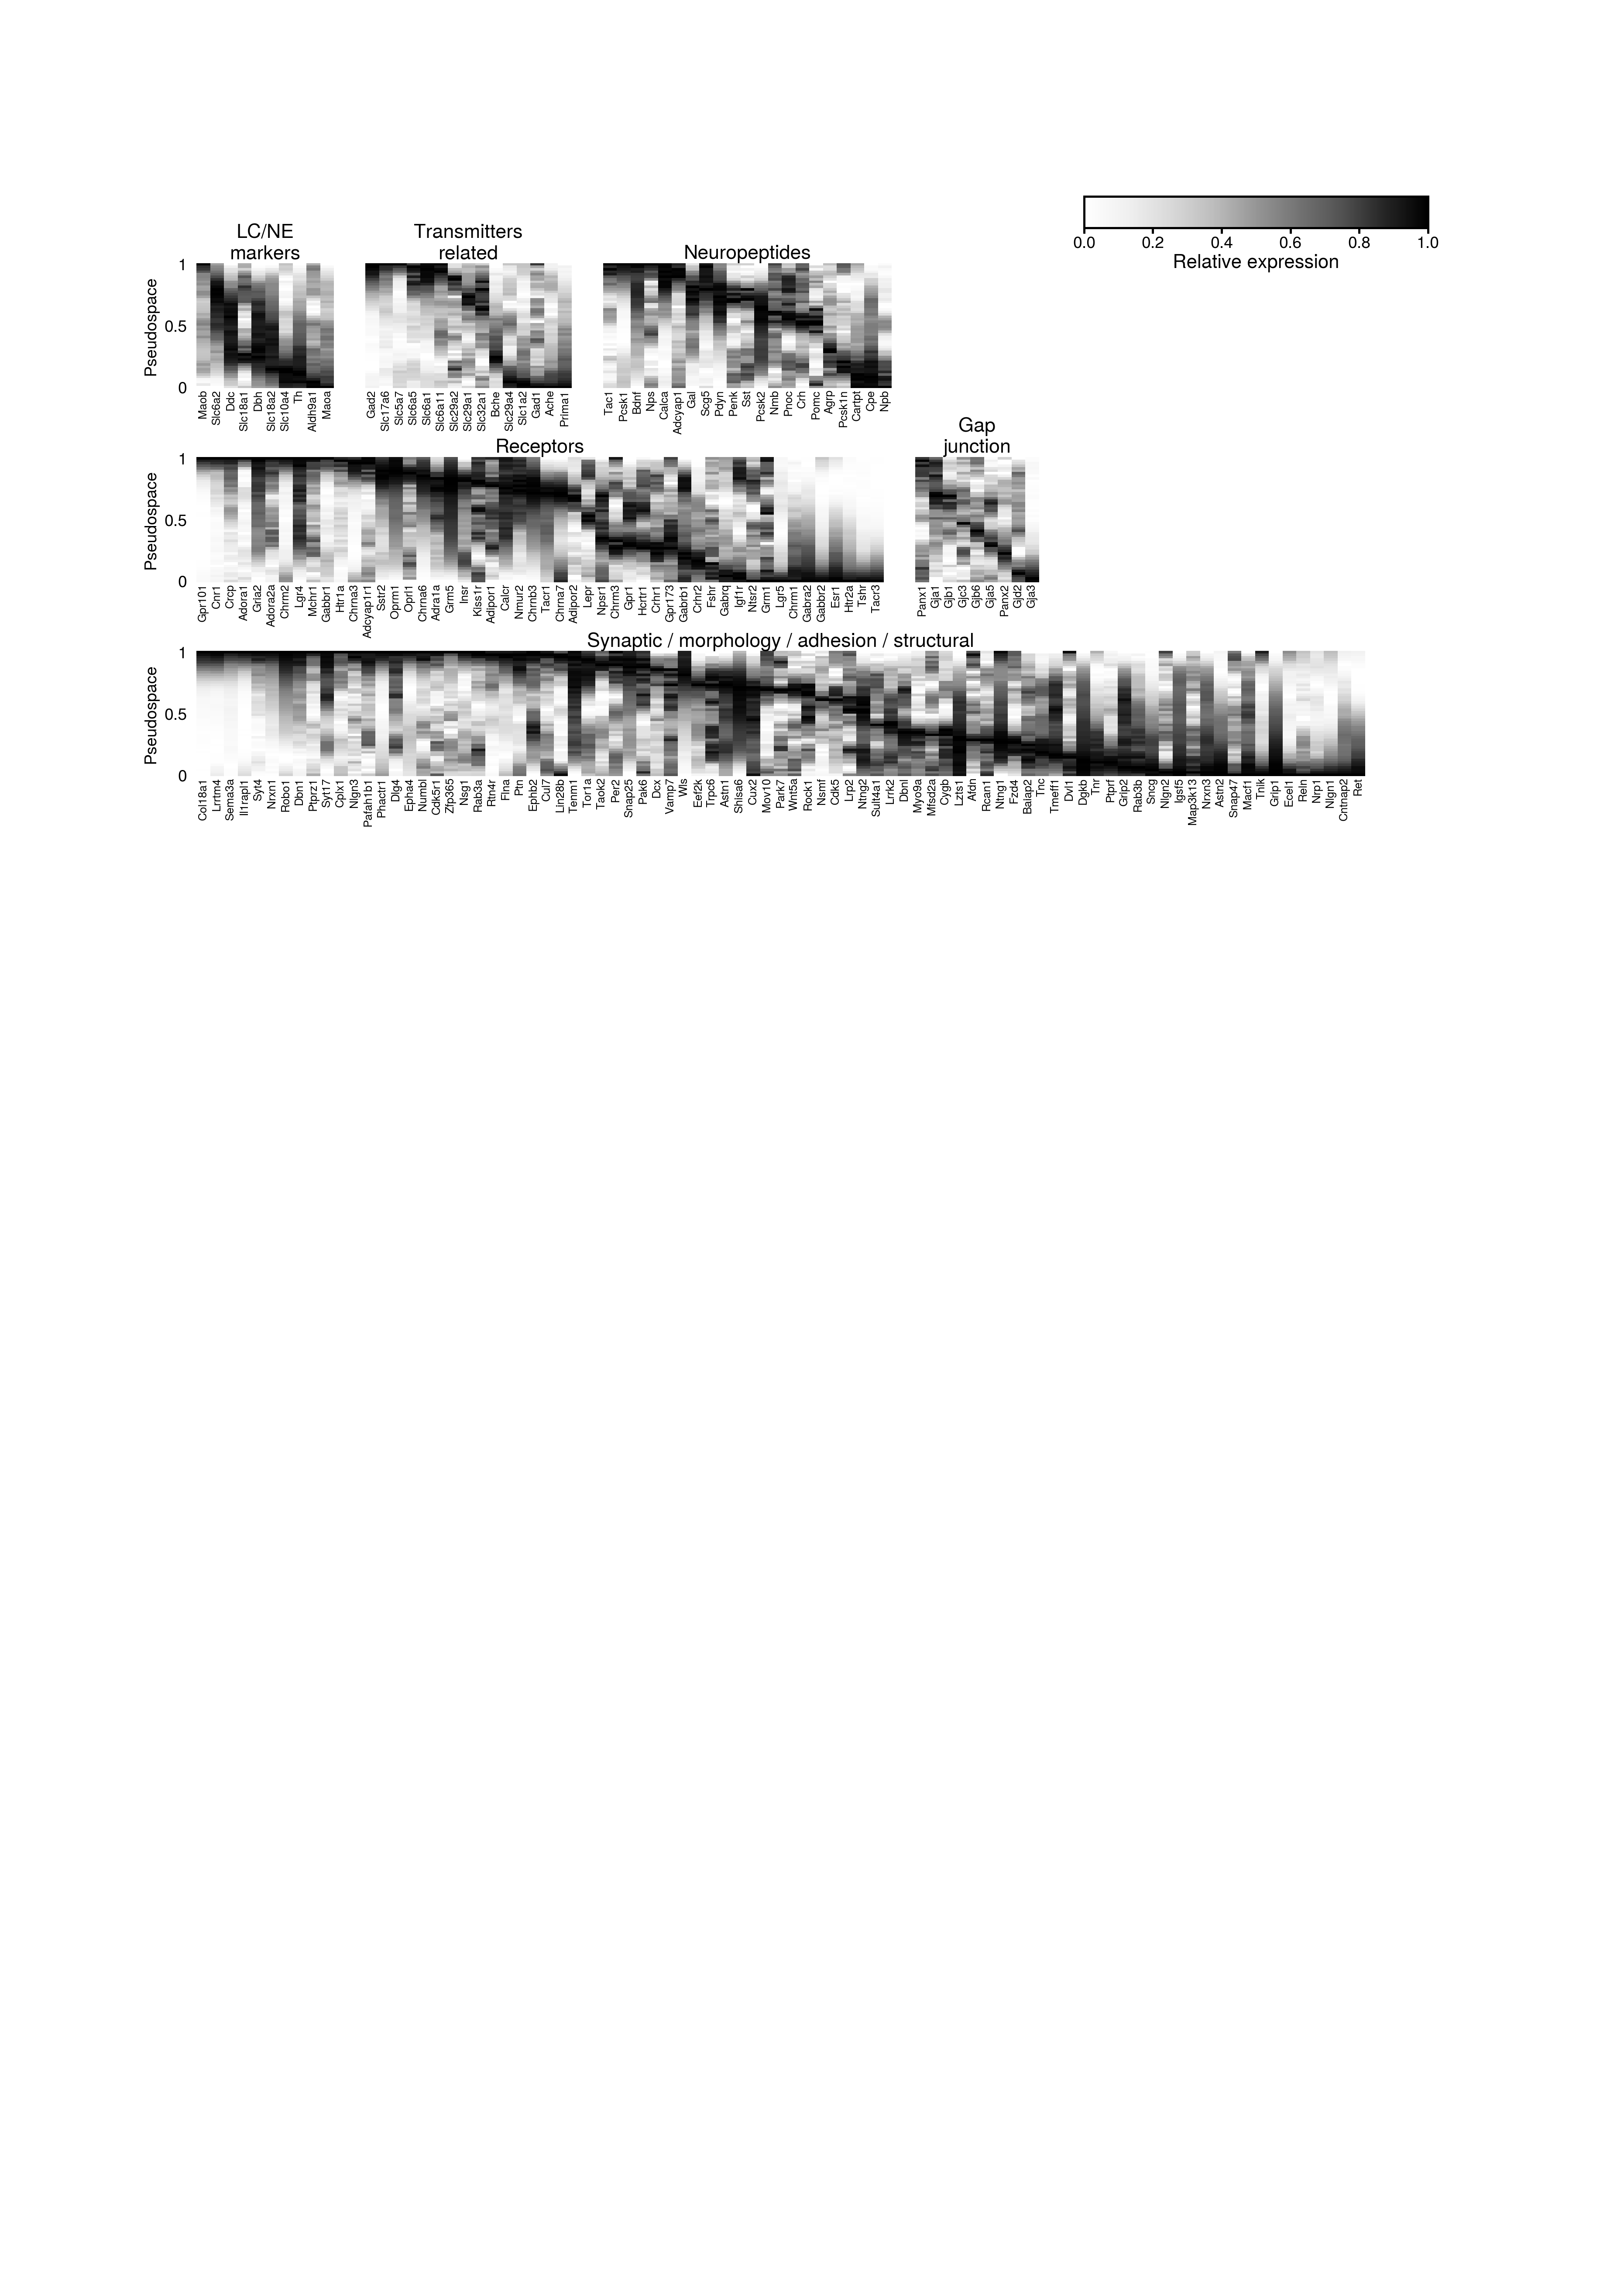

Saved PNG: /results/fig_S9/fig_S9_2026-07-16.png
Saved PDF: /results/fig_S9/fig_S9_2026-07-16.pdf
Saved layout: /results/fig_S9/LCNE_simplified_relative_peak1to0_notebook_layout.csv


,row,position_in_row,category,n_genes,panel_width_in,gene_column_width_in
0,1,1,LC/NE markers,10,0.70,0.07
1,1,2,Transmitters related,15,1.05,0.07
2,1,3,Neuropeptides,21,1.47,0.07
3,2,1,Receptors,50,3.50,0.07
4,2,2,Gap junction,9,0.63,0.07
5,3,1,Synaptic / morphology / adhesion / structural,85,5.95,0.07


In [9]:
rows = compute_flow_layout(panels)
fig = plt.figure(figsize=A4_PORTRAIT_IN)
fig.patch.set_facecolor("white")
page_width, page_height = A4_PORTRAIT_IN

def add_panel(fig, panel, left_in, bottom_in, show_y_ticks):
    ax = fig.add_axes([
        left_in / page_width,
        bottom_in / page_height,
        panel["width_in"] / page_width,
        HEATMAP_HEIGHT_IN / page_height,
    ])
    sns.heatmap(
        panel["data"].T,
        ax=ax,
        cmap="Greys",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=panel["genes"],
        yticklabels=False,
    )
    max_chars = max(6, int(panel["width_in"] / GENE_COLUMN_WIDTH_IN))
    wrapped_title = "\n".join(textwrap.wrap(panel["category"], width=max_chars, break_long_words=False, break_on_hyphens=False))
    ax.set_title(wrapped_title, fontsize=TITLE_FONTSIZE, pad=1.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=90, labelsize=XTICK_FONTSIZE, length=0, pad=0.5)
    ax.tick_params(axis="y", length=0)
    if show_y_ticks:
        ax.set_yticks(np.linspace(0, panel["data"].shape[1] - 1, 3) + 0.5)
        ax.set_yticklabels(["0", "0.5", "1"], rotation=0, fontsize=YTICK_FONTSIZE)
        ax.set_ylabel("Pseudospace", fontsize=YTICK_FONTSIZE, labelpad=2)
    ax.invert_yaxis()
    ax.grid(False)

row_top = page_height - TOP_MARGIN_IN - HEADER_HEIGHT_IN
for row_index, row in enumerate(rows):
    bottom = row_top - HEATMAP_HEIGHT_IN - row_index * (HEATMAP_HEIGHT_IN + PANEL_GAP_Y_IN)
    left = LEFT_MARGIN_IN
    for panel_index, panel in enumerate(row):
        add_panel(fig, panel, left, bottom, show_y_ticks=(panel_index == 0))
        left += panel["width_in"] + PANEL_GAP_X_IN

cbar_left = page_width - RIGHT_MARGIN_IN - CBAR_WIDTH_IN
cbar_bottom = page_height - TOP_MARGIN_IN - CBAR_HEIGHT_IN
cbar_ax = fig.add_axes([cbar_left / page_width, cbar_bottom / page_height, CBAR_WIDTH_IN / page_width, CBAR_HEIGHT_IN / page_height])
scalar = ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap="Greys")
cbar = fig.colorbar(scalar, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Relative expression", fontsize=7, labelpad=1)
cbar.ax.tick_params(labelsize=6, length=2, pad=1)

OUT_DIR.mkdir(parents=True, exist_ok=True)
out_png = OUT_DIR / f"{FIGURE_NAME}.png"
out_pdf = OUT_DIR / f"{FIGURE_NAME}.pdf"
fig.savefig(out_png, dpi=DPI)
fig.savefig(out_pdf)
plt.close(fig)

# Display the exported PNG inline so the result is visible in the notebook
# (the Agg backend used above does not render figures interactively).
from IPython.display import Image, display
display(Image(filename=str(out_png)))

layout = pd.DataFrame([
    {
        "row": row_index + 1,
        "position_in_row": panel_index + 1,
        "category": panel["category"],
        "n_genes": panel["n_genes"],
        "panel_width_in": panel["width_in"],
        "gene_column_width_in": GENE_COLUMN_WIDTH_IN,
    }
    for row_index, row in enumerate(rows)
    for panel_index, panel in enumerate(row)
])

layout_csv = OUT_DIR / f"{FIGURE_BASENAME}_layout.csv"
layout.to_csv(layout_csv, index=False)
print(f"Saved PNG: {out_png}")
print(f"Saved PDF: {out_pdf}")
print(f"Saved layout: {layout_csv}")
display(layout)

## Export Per-Panel Heatmap Matrices

Write one CSV per panel containing the heatmap matrix exactly as plotted: rows are pseudospace positions (0 -> 1), columns are genes in left-to-right plot order, and values are the relative expression (0-1) shown in the greyscale cells.

In [7]:
import re

def _slugify(name):
    return re.sub(r"[^0-9A-Za-z]+", "_", name).strip("_").lower()

# Actual normalized pseudospace score at each of the N_OUT plotted positions
# (identical across panels since they share the same cells/positions).
position_scores = (
    essential_df[essential_df["category"] == panels[0]["category"]]
    .drop_duplicates("pseudospace_index")
    .sort_values("pseudospace_index")["pseudospace_score"]
    .to_numpy()
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
panel_csv_paths = []
for panel in panels:
    # panel["data"] is genes x N_OUT (relative expression). Transpose to match the
    # plotted orientation: rows = pseudospace positions, columns = genes.
    matrix = pd.DataFrame(panel["data"].T, columns=panel["genes"])
    matrix.insert(0, "pseudospace", position_scores)
    out_csv = OUT_DIR / f"figS9_{_slugify(panel['category'])}.csv"
    matrix.to_csv(out_csv, index=False)
    panel_csv_paths.append(out_csv)
    print(f"Saved panel CSV ({panel['category']}): {out_csv}")

print(f"\nSaved {len(panel_csv_paths)} panel CSV files to {OUT_DIR}")


Saved panel CSV (LC/NE markers): /results/fig_S9/figS9_lc_ne_markers.csv
Saved panel CSV (Transmitters related): /results/fig_S9/figS9_transmitters_related.csv
Saved panel CSV (Neuropeptides): /results/fig_S9/figS9_neuropeptides.csv
Saved panel CSV (Receptors): /results/fig_S9/figS9_receptors.csv
Saved panel CSV (Gap junction): /results/fig_S9/figS9_gap_junction.csv
Saved panel CSV (Synaptic / morphology / adhesion / structural): /results/fig_S9/figS9_synaptic_morphology_adhesion_structural.csv

Saved 6 panel CSV files to /results/fig_S9


hostname: e03fc55f49d8
cwd: /root/capsule/code/notebooks/snRNA


NameError: name 'OUT_DIR' is not defined